In [28]:
%matplotlib ipympl
import sys
import os
sys.path.append("../../src/")
import matplotlib.pyplot as plt

import cdsaxs
import numpy as np

import cdsaxs.loaders
import cdsaxs.loaders.load_data
import cdsaxs.data
import cdsaxs.plotting


In [40]:
# set the path to the CSV metadata file for the validation data and create the dataset
csv_path = os.path.abspath("data_W204_F2/W204_metadata.csv")

In [41]:
data_dir = "./data_W204_F2/"
filename_pattern = "W204_F2measure1_{sdd_cm}m_{energy_ev}keV_num{num}_{sample_phi_deg}deg_bpm{bpm}_id{id}_combined.tif"

In [42]:
dataset = cdsaxs.loaders.load_data.LoadDataset("validation set", data_dir, metadata_pattern=filename_pattern, metadata_scales = {'energy_ev': 1000}, metadata={'exposure_time_s': 2}, filetype='tif')

Loading files: 100%|█████████████████████████████████████████████| 121/121 [00:05<00:00, 22.91it/s]

The following metadata is missing to calculate the beam coordinate scattering vector: ['pixel_size_um', 'center_px', 'detector_phi_deg', 'detector_phi0_deg', 'detector_phi_scale', 'detector_y_mm', 'detector_y0_mm']. Therefore, the sample coordinatescattering vector also could not be calculated
The following metadata is missing to calculate the beam coordinate scattering vector: ['sample_phi_offset_deg', 'sample_omega_deg', 'sample_omega_offset_deg', 'sample_chi_deg', 'sample_chi_offset_deg']. Therefore, the sample coordinatescattering vector also could not be calculated
No data type known for center_px.
Insufficient metadata to calculate q. Check your metadata to ensure the correct center position, wavelength, sample to detector distance, and pixel size are provided.
Created dataset from data directory: C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\tests\validation\data_W204_F2


In [43]:
# use identical beam center position and sample-to-detector position as the GUI
# set the pixel size for Pilatus detector
dataset.update_all_metadata({'sdd_cm': 504.982, 'center_px': [738, 492], 'pixel_size_um': 172}, overwrite=True)
# dataset.update_all_metadata({'sdd_cm': 504.982, 'center_px': [738, 488], 'pixel_size_um': 172}, overwrite=True) # we are not flipping the images so need to update beam center

Updating datas:   0%|                                                      | 0/121 [00:00<?, ?it/s]C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\tests\validation\../../src\cdsaxs\data\metadata.py:89: UserWarning: No data type known for center_px.
  warnings.warn(
C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\tests\validation\../../src\cdsaxs\data\metadata.py:89: UserWarning: No data type known for center_px_detector.
  warnings.warn(
Updating datas: 100%|████████████████████████████████████████████| 121/121 [00:33<00:00,  3.66it/s]


In [44]:
# # rotate all images by 180 degrees to match GUI axis alignments
# for data in dataset.datas.values():
#     data.rotate_image_ccw(2)

# data = dataset.datas["W204_F2measure1_5.2m_16.1keV_num60_00deg_bpm0.417_id857181_combined.tif"]
# fig = data.plot_data()

In [45]:
data = dataset.datas["W204_F2measure1_5.2m_16.1keV_num60_00deg_bpm0.417_id857181_combined.tif"]
data.metadata

{'exposure_time_s': 2.0,
 'sdd_cm': 504.982,
 'energy_ev': 16100.000000000002,
 'wavelength_nm': 0.07700882268401862,
 'sample_phi_deg': 0.0,
 'data_directory': 'C:\\Users\\cmw5\\Documents\\github_repos\\nist_cdsaxs\\tests\\validation\\data_W204_F2',
 'filename': 'W204_F2measure1_5.2m_16.1keV_num60_00deg_bpm0.417_id857181_combined.tif',
 'sample_phi_offset_deg': 0.0,
 'sample_chi_deg': 0.0,
 'sample_chi_offset_deg': 0.0,
 'sample_omega_deg': 0.0,
 'sample_omega_offset_deg': 0.0,
 'detector_phi_deg': 0.0,
 'detector_phi0_deg': 0.0,
 'detector_phi_scale': 1.0,
 'detector_y_mm': 0.0,
 'detector_y0_mm': 0.0,
 'center_px': [738, 492],
 'pixel_size_um': 172.0,
 'center_px_detector': (738.0, 492.0)}

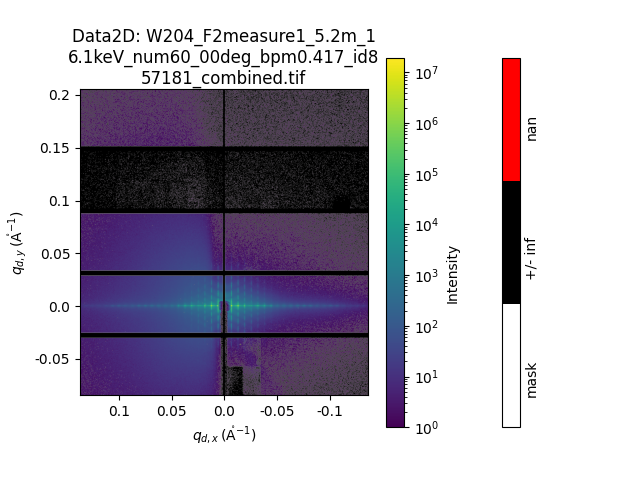

In [46]:
fig = data.plot_data()

In [47]:
# normalize by count time
dataset.normalize_all_data_by_metadata(['exposure_time_s'])

C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\tests\validation\../../src\cdsaxs\plotting\plotting.py:357: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\tests\validation\../../src\cdsaxs\plotting\plotting.py:257: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(
C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\tests\validation\../../src\cdsaxs\plotting\plotting.py:357: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


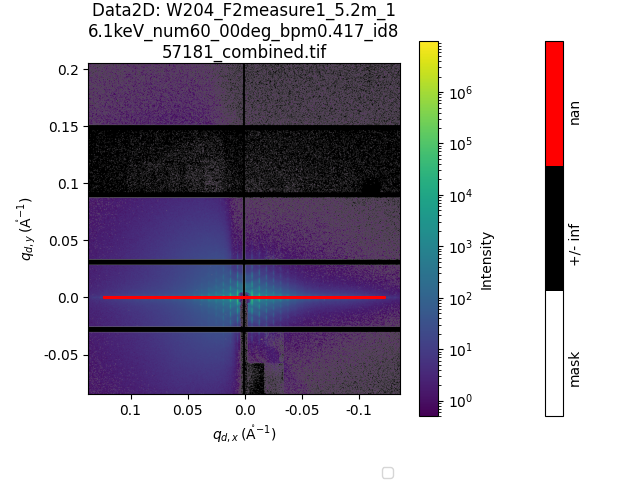

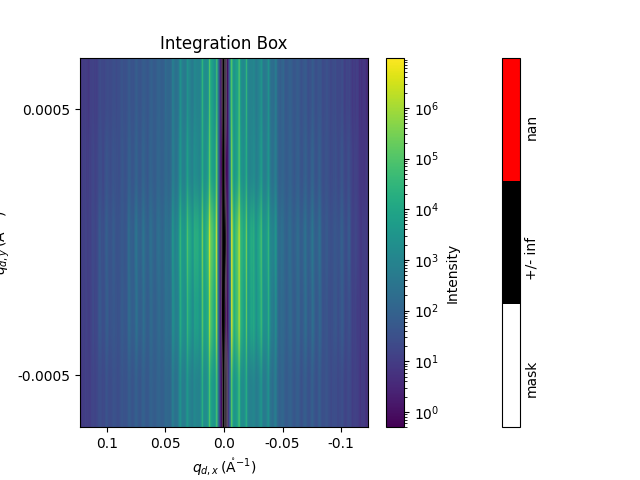

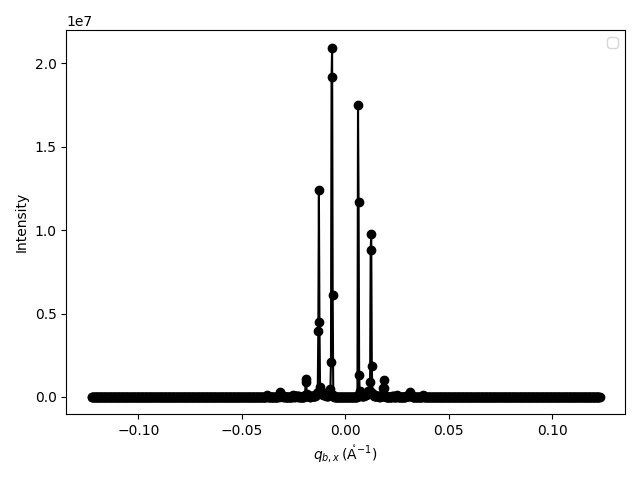

In [48]:
qslice = data.integrate_box('sum', width_qdy_px=5, width_qdx_px=884)

C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\tests\validation\../../src\cdsaxs\plotting\plotting.py:1509: UserWarning: Log scale: values of z <= 0 have been masked
  data_plot = plt.contourf(


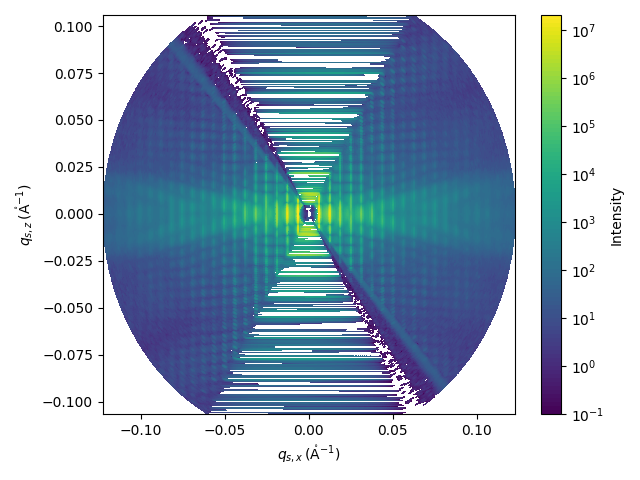

In [49]:
integrated_dataset = dataset.integrate_dataset('sum', width_qdy_px=5, width_qdx_px=884)
fig = integrated_dataset.plot_data(interpolated_data=True)

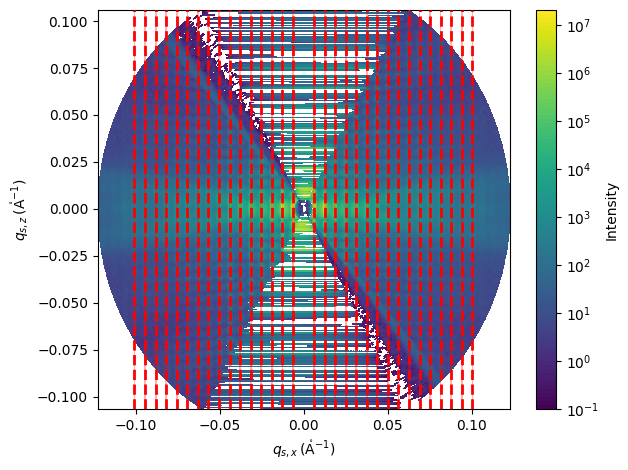

In [56]:
# the slice points (q_values) matches the slices taken in the GUI
q_values = -1*np.array([0.006441, 0.01275, 0.01904, 0.02532, 0.03156, 0.03788, 0.04412, 0.05044, 0.05672, 0.06294, 0.06923, 0.07553, 0.08187, 0.08805, 0.09442, 0.1007, -0.006155, -0.01249, -0.01871, -0.02496, -0.03124, -0.03751, -0.04373, -0.05005, -0.0563, -0.06248, -0.06883, -0.07513, -0.08133, -0.08767, -0.09397, -0.1003]) 
reduced_slices, fig = cdsaxs.reduction.slice_reduced_dataset(integrated_dataset, q_values=q_values, q_widths=0.001, plotting_kwargs={'s': 0.5, 'interpolated_data': True})

In [57]:
# the dictionary of reduced slices from the refactored code will be referenced as 'refactored_slices'
refactored_slices = {}
for data in reduced_slices.data:
    refactored_slices[float(data.qsx)] = data

In [58]:
# load the reduced slices from the legacy gui as 'legacy_slices'
legacy_file = "LegacyGUISlices_LargerWidthSlices0p001_20250509.csv"
file = open(legacy_file)
data = file.readlines()
file.close()
data = [x.split(',') for x in data]
data = np.array(data, dtype=str)
header = data[0, :]

legacy_slices = {}

for i in range(0, int(header.shape[0]/2)):
    qz = data[1:, i*2]
    iqz = data[1:, i*2+1]

    selection = np.where(qz!='')

    qz = qz[selection].astype(np.float64)
    iqz = iqz[selection].astype(np.float64)

    head = header[i*2+1]
    head = head.split('=')
    head = head[-1]
    if head[-2:] == '\n':
        head = head[:-2]

    qx = np.float64(head)

    legacy_slices[float(np.round(qx, 4))] = cdsaxs.data.data1d.Data1D(q=qz, Iq=iqz, q_axis='qsz')

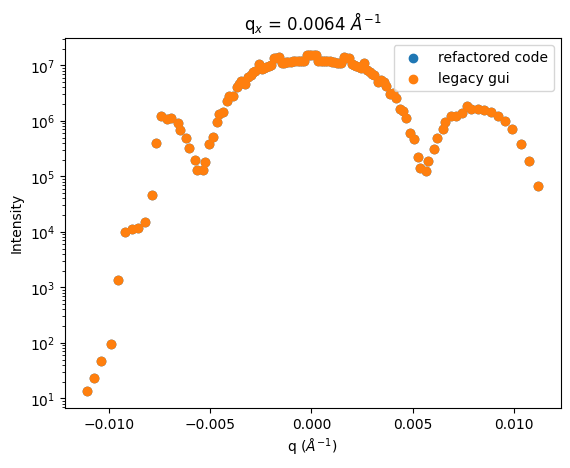

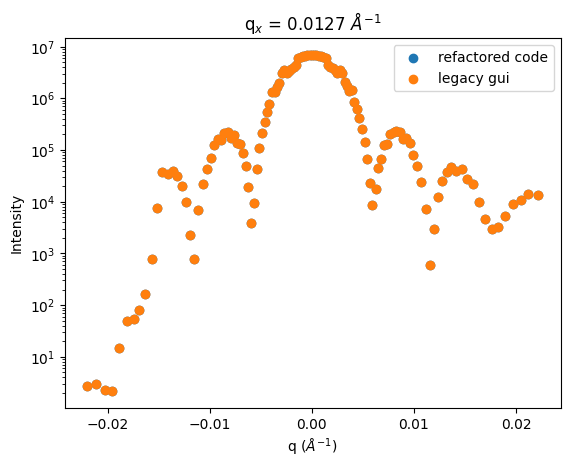

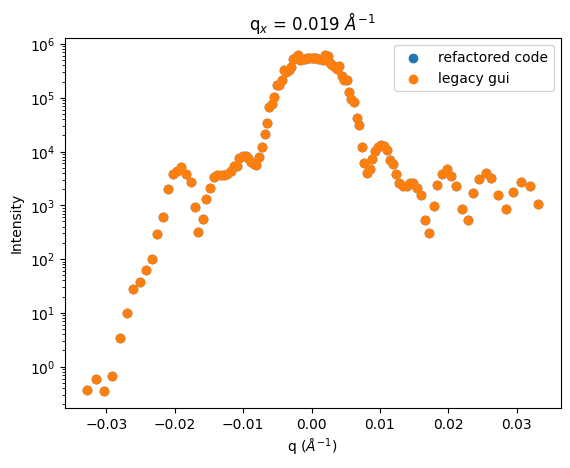

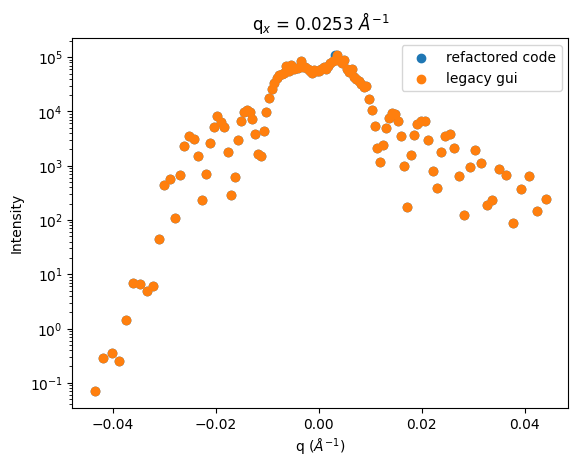

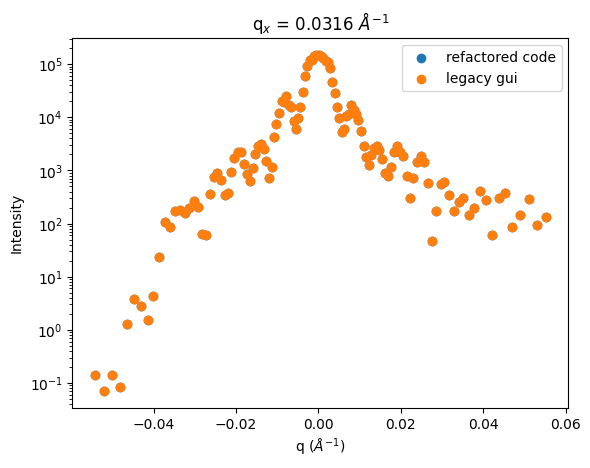

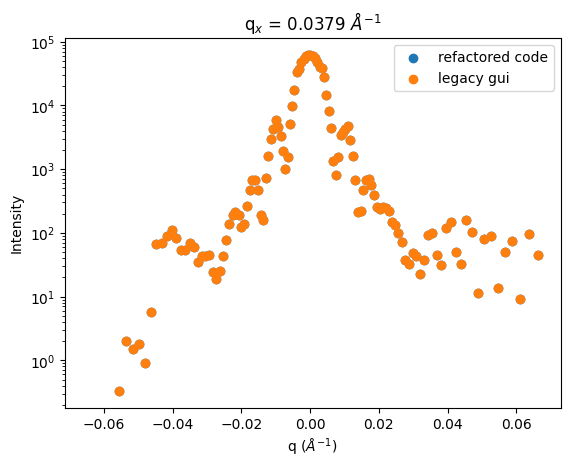

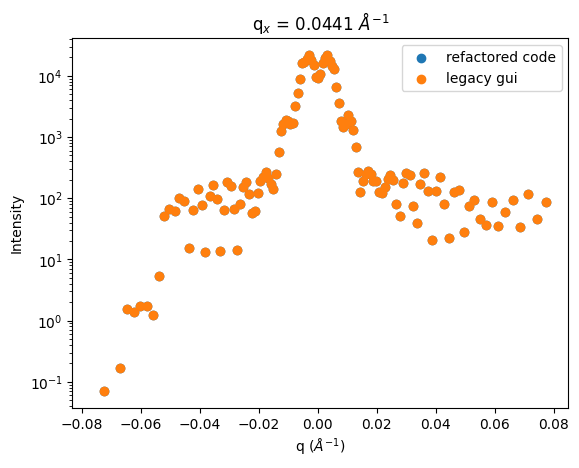

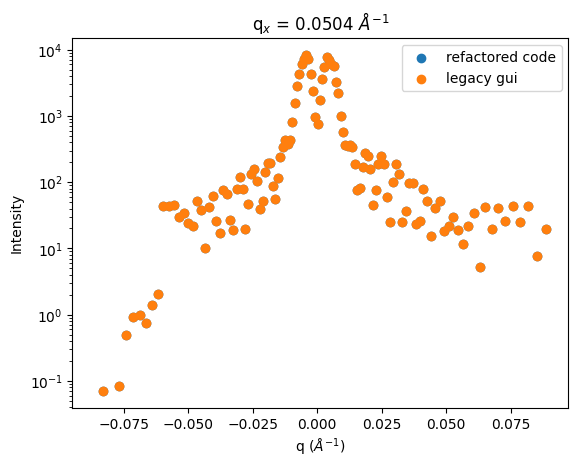

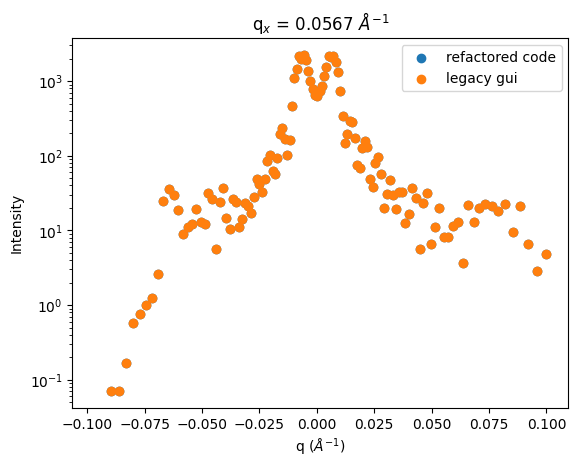

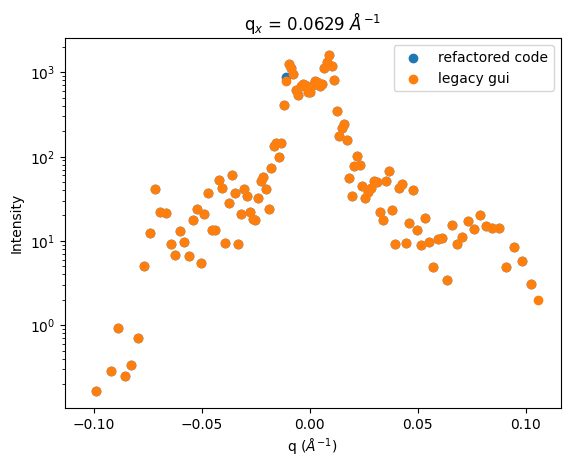

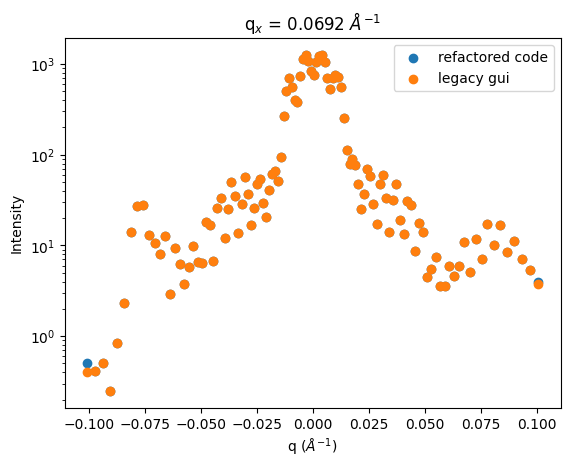

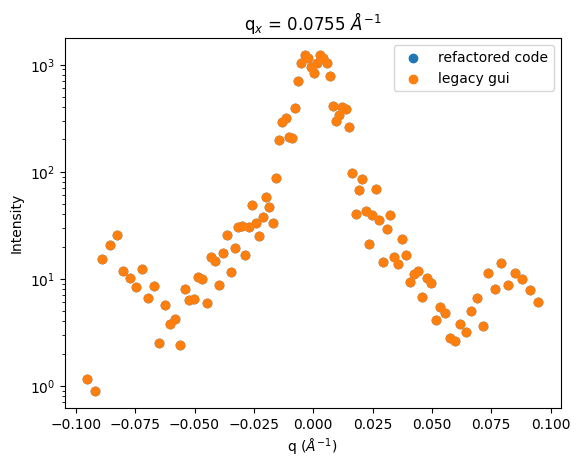

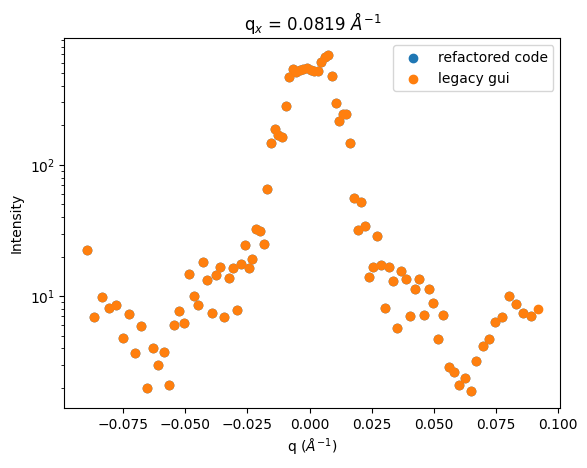

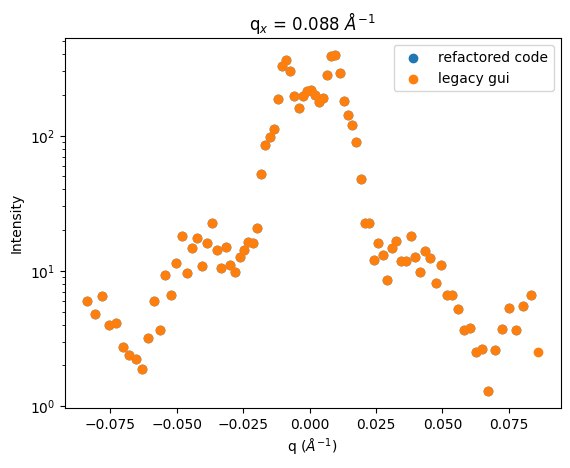

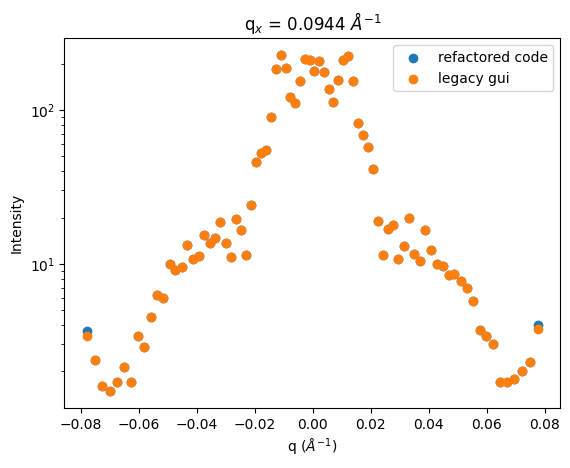

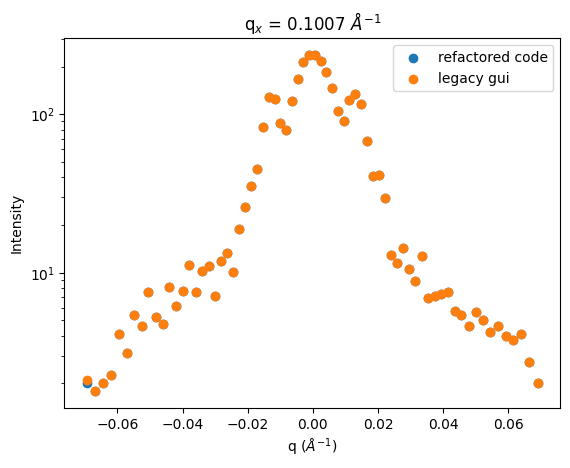

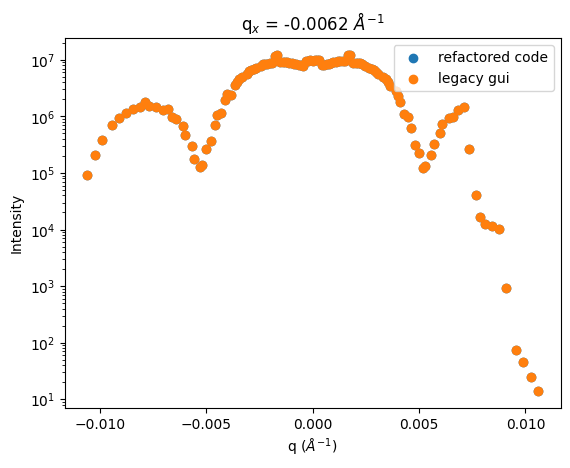

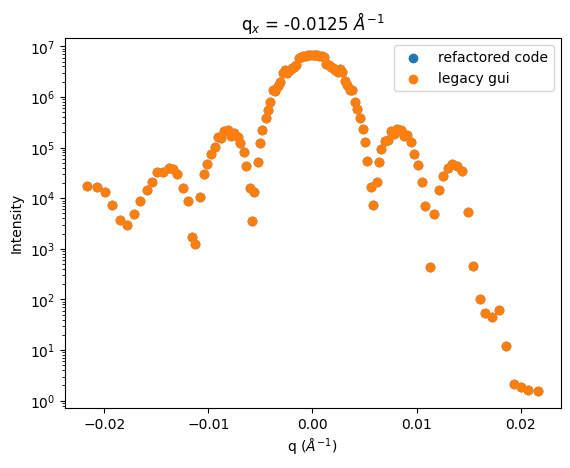

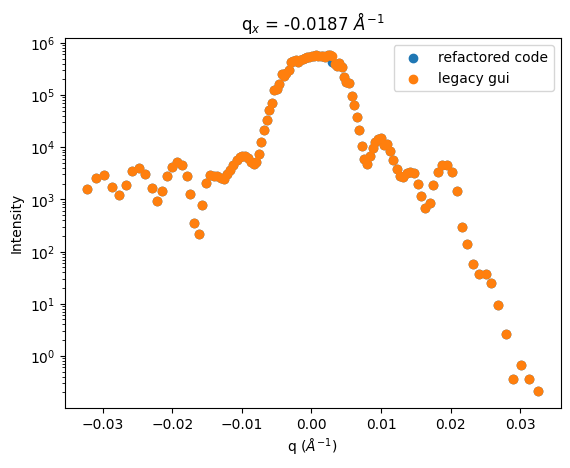

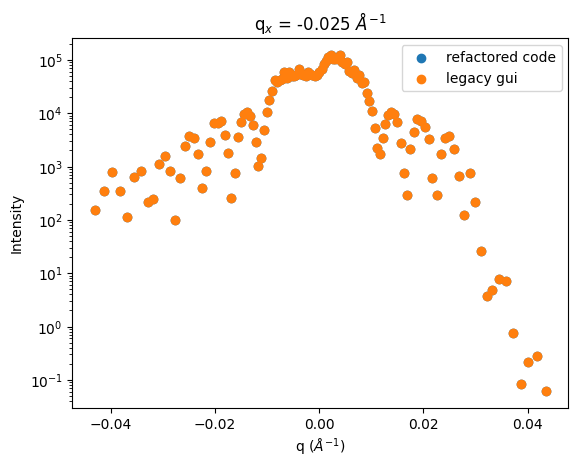

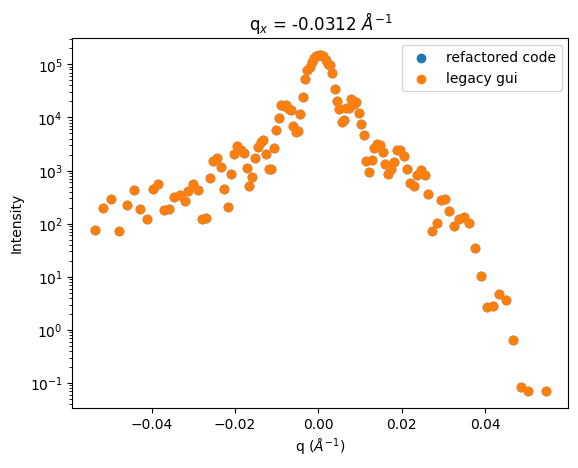

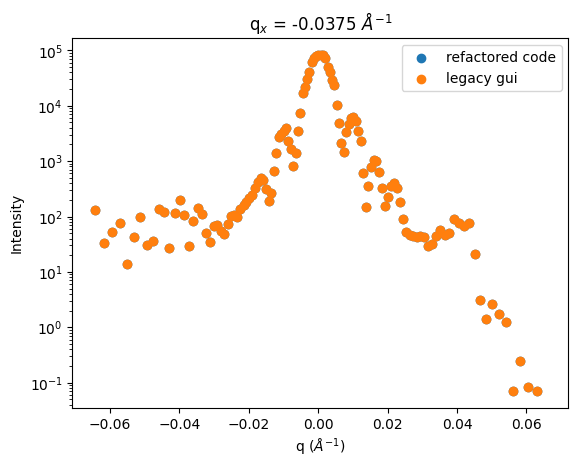

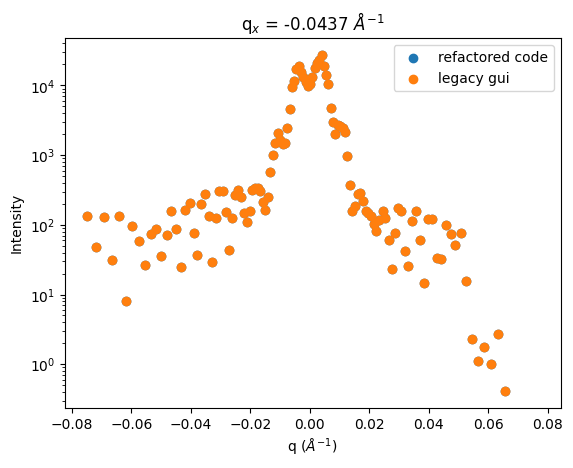

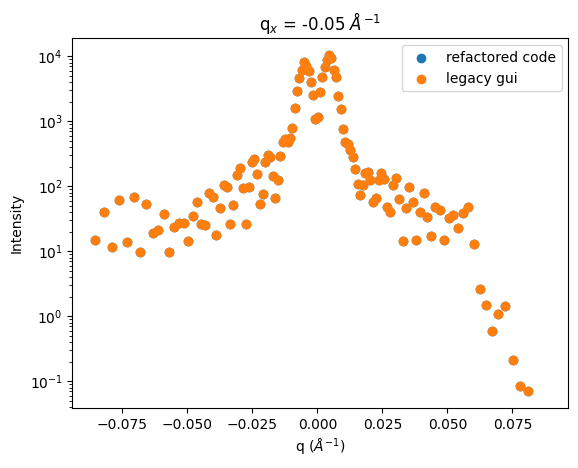

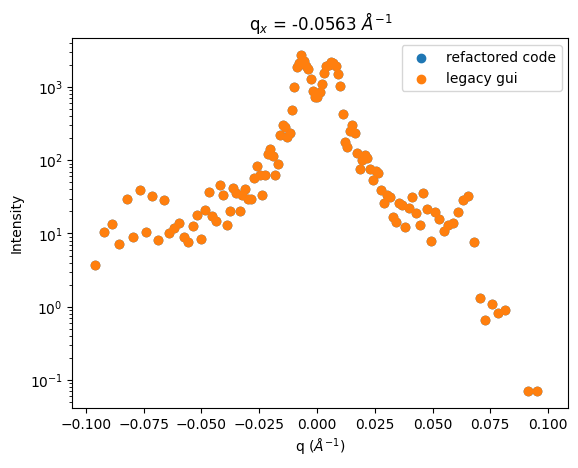

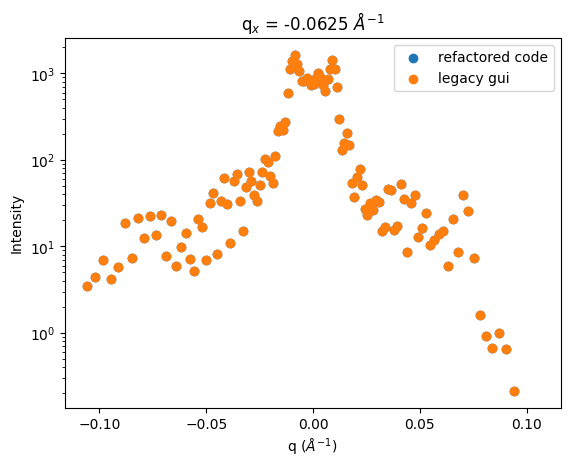

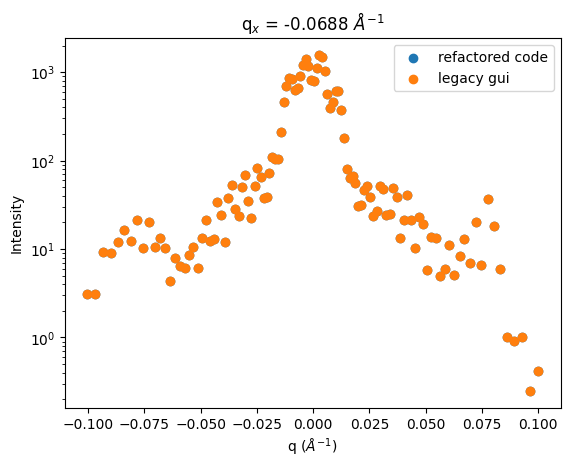

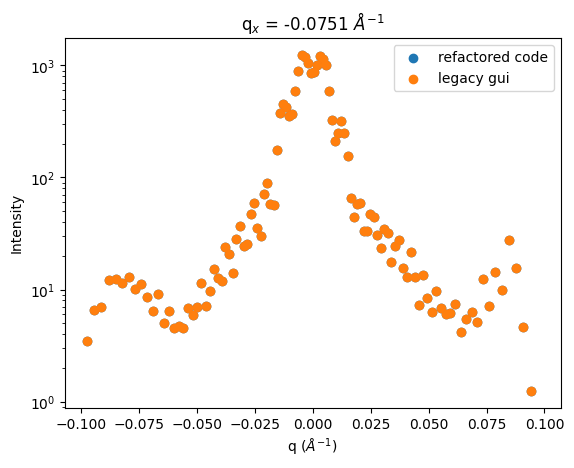

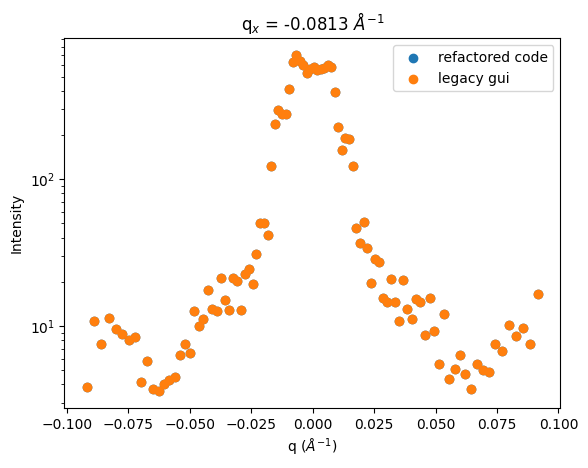

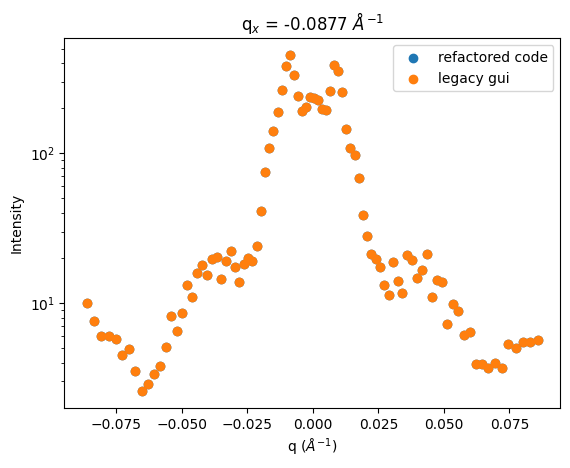

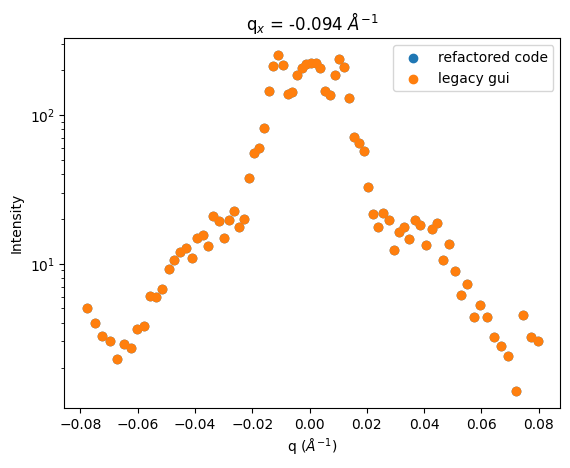

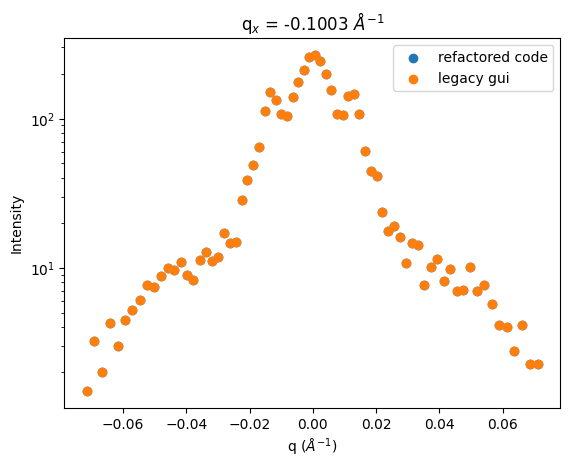

In [64]:
%matplotlib inline
plt.close('all')
# plot each slice from the refactored code with the matching slice from the legacy gui
for qx in legacy_slices.keys():
    plt.figure()

    # the coordinate systems differ between old gui and new code so there is a sign flip along qsx and qsz!
    slice_legacy = legacy_slices[qx]
    slice_refactor = refactored_slices[-1*qx]
    
    plt.scatter(-1*slice_refactor.q, slice_refactor.Iq, label='refactored code')
    plt.scatter(slice_legacy.q, slice_legacy.Iq*1, label='legacy gui')

    plt.legend()

    # plt.xlim(-0.001, 0.001)
    
    plt.title(r"q$_x$ = "+str(qx)+r" $\AA^{-1}$")
    plt.ylabel("Intensity")
    plt.xlabel(r"q ($\AA^{-1}$)")
    plt.yscale('log')
    plt.show()
    plt.close()

    # break

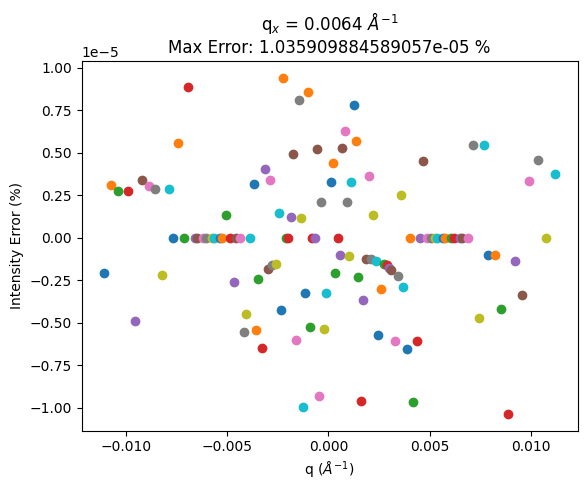

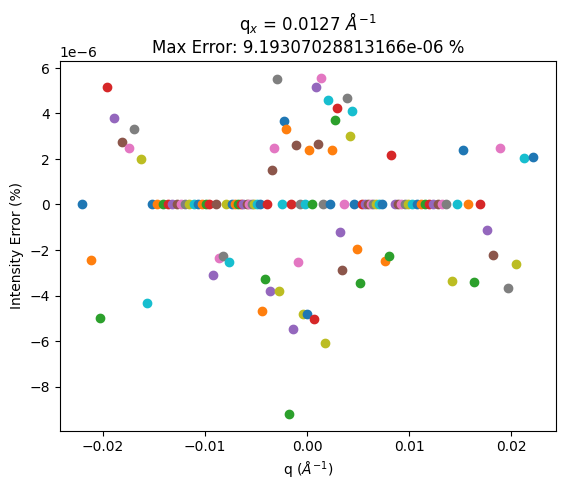

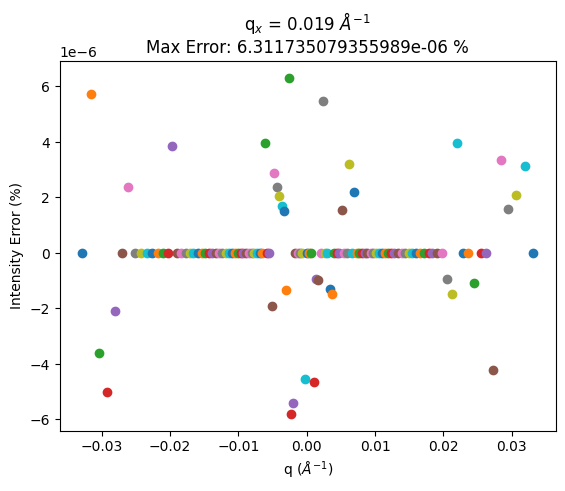

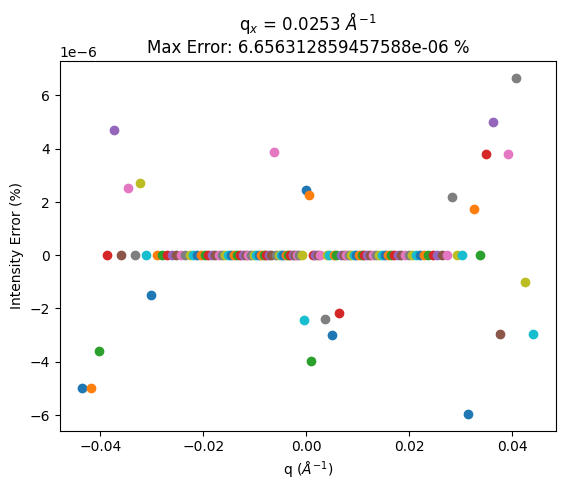

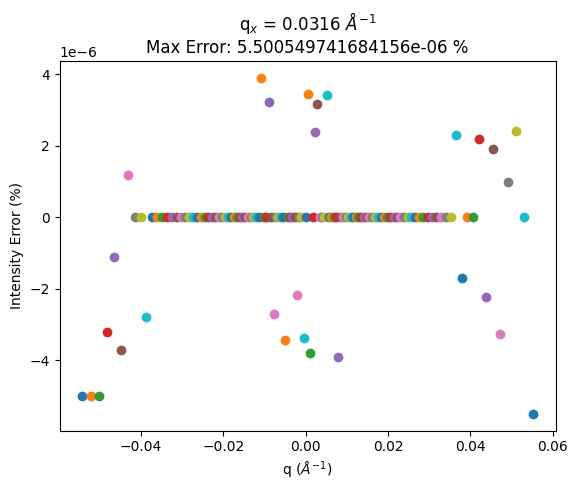

C:\Users\cmw5\AppData\Local\Temp\ipykernel_23884\1514326485.py:17: RuntimeWarning: invalid value encountered in scalar divide
  error = (slice_refactor.Iq[close_match] - slice_legacy.Iq[i])*100/slice_legacy.Iq[i]


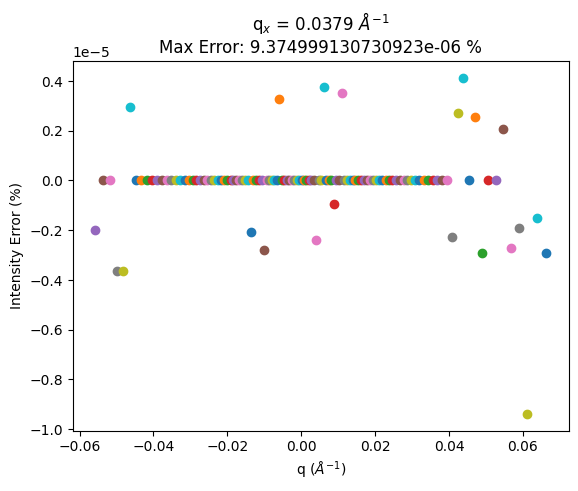

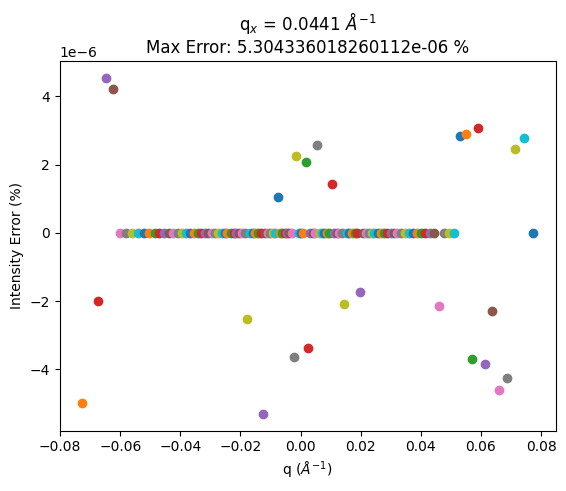

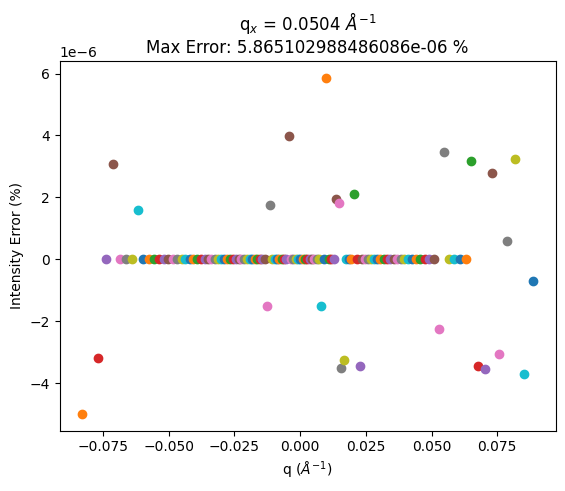

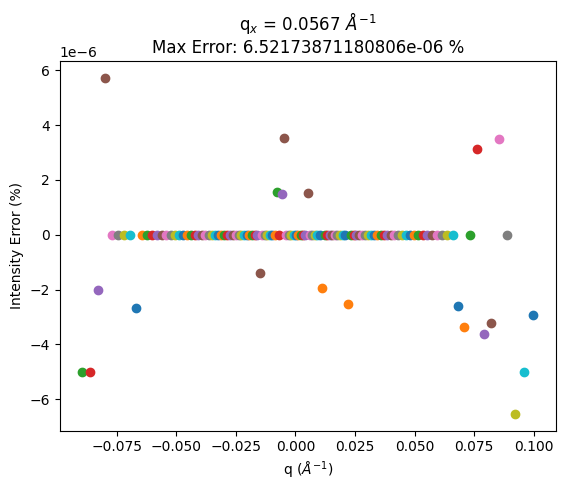

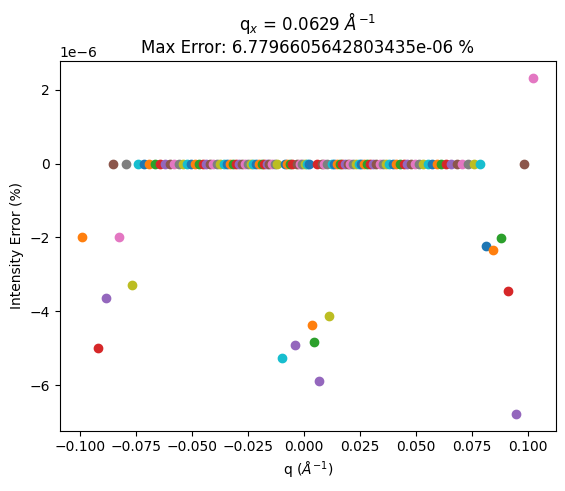

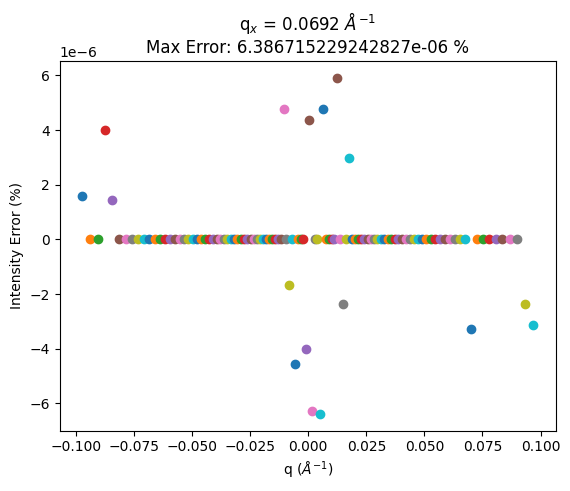

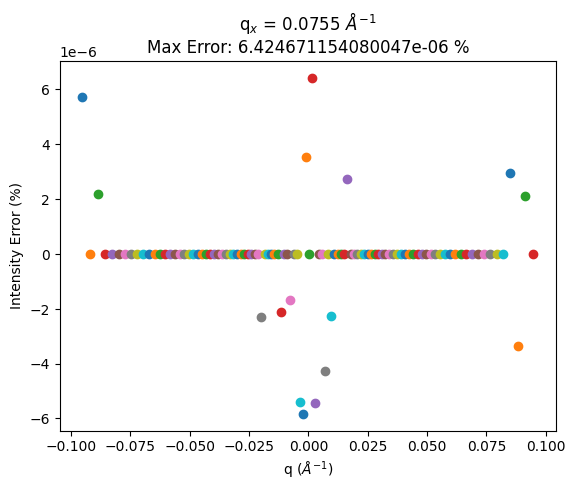

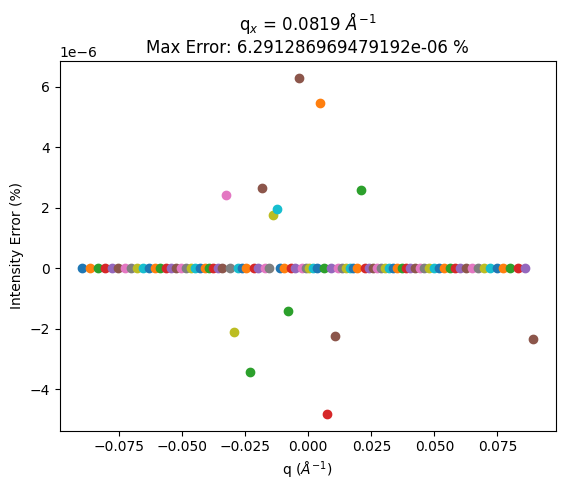

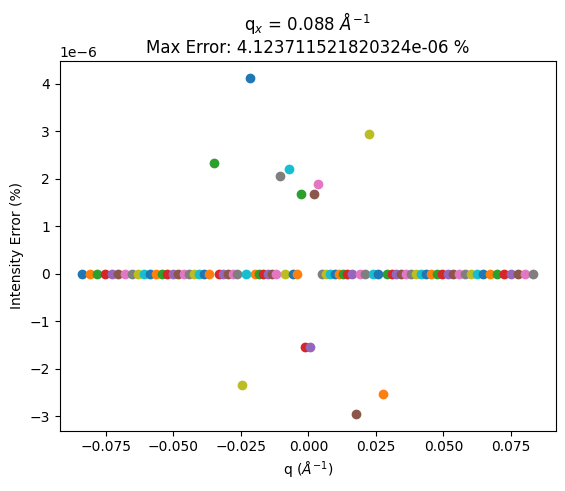

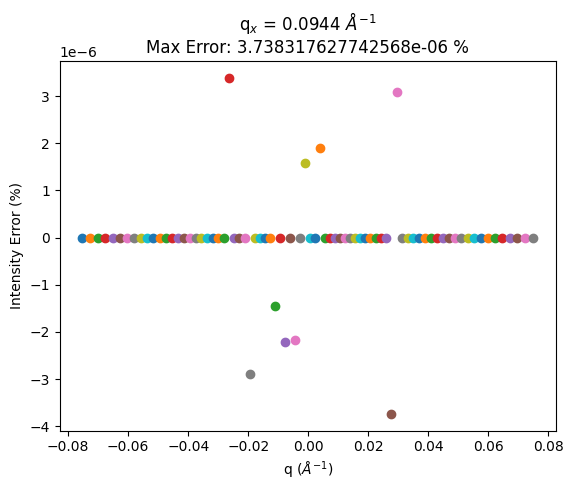

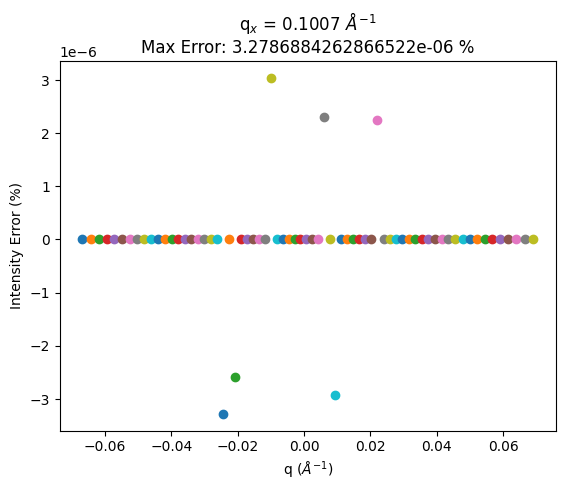

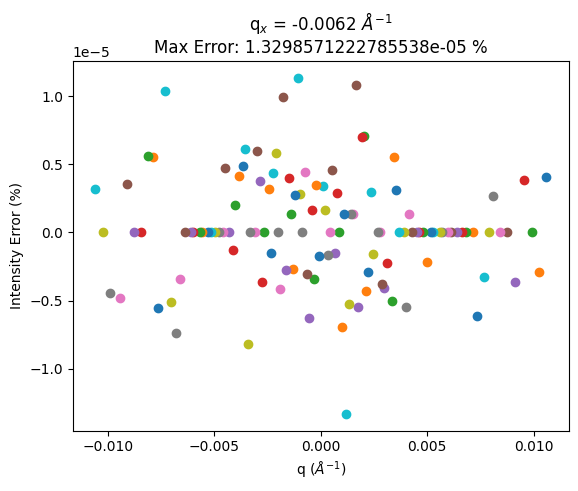

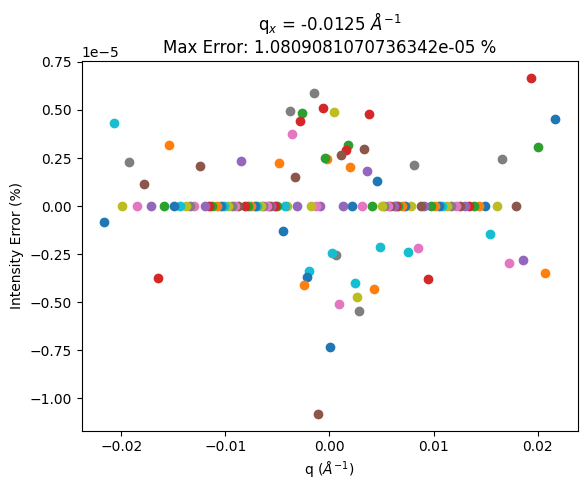

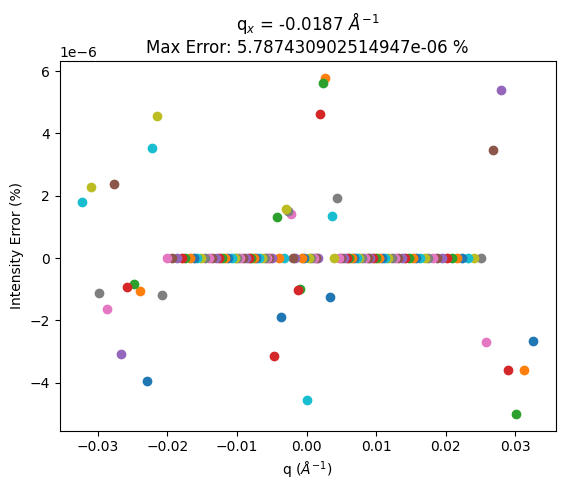

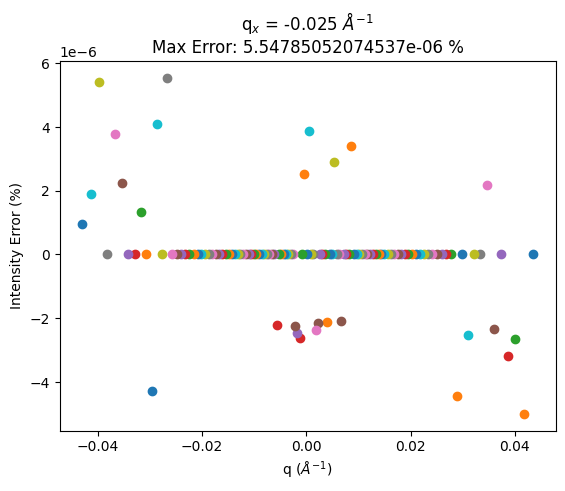

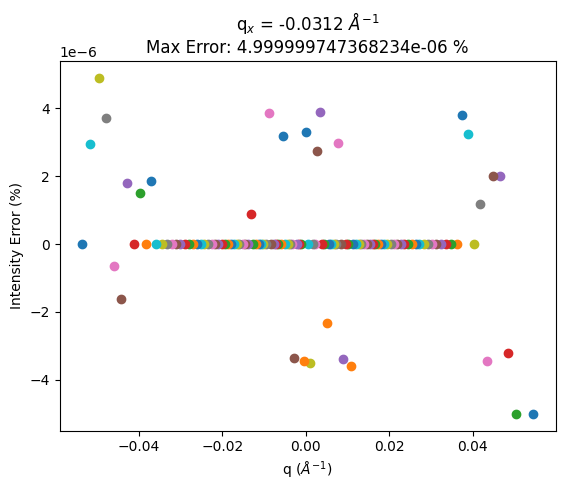

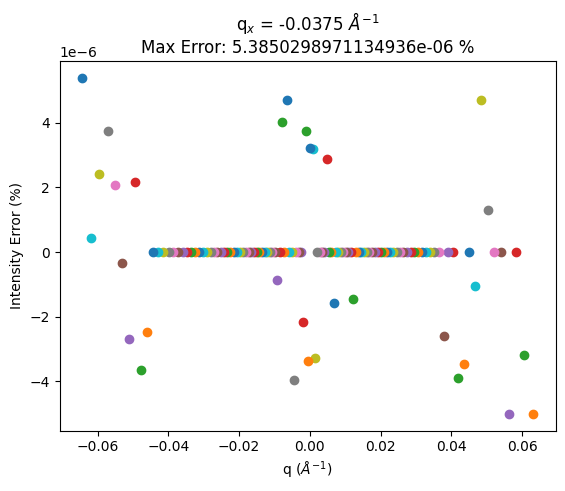

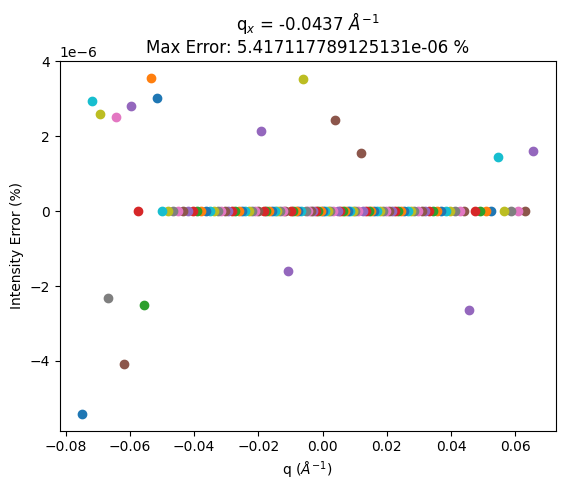

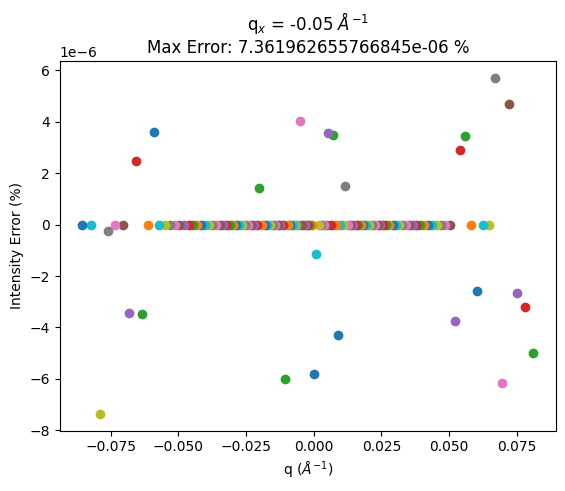

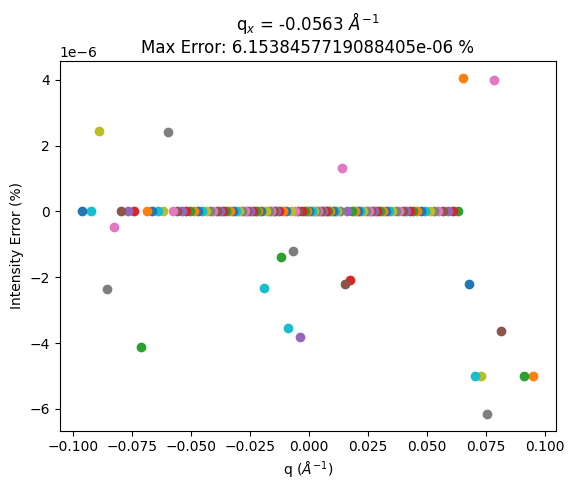

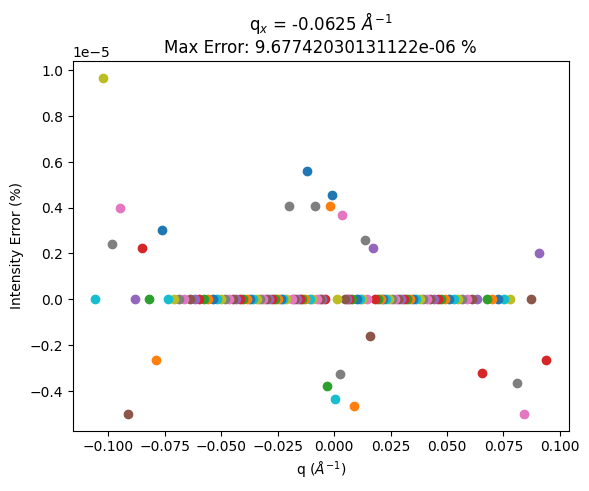

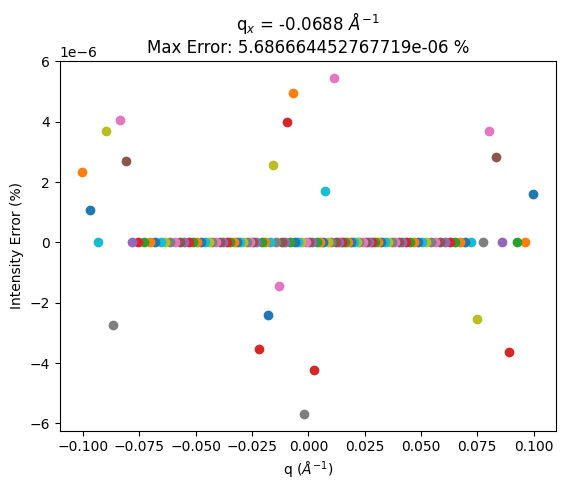

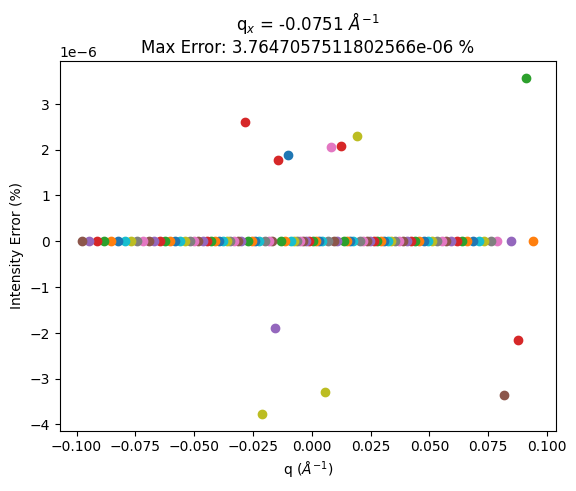

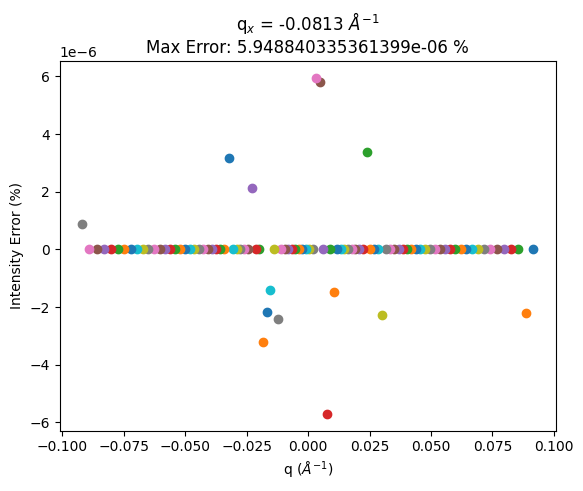

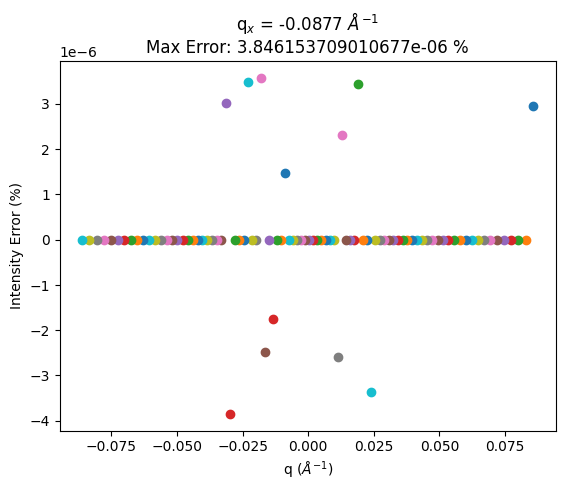

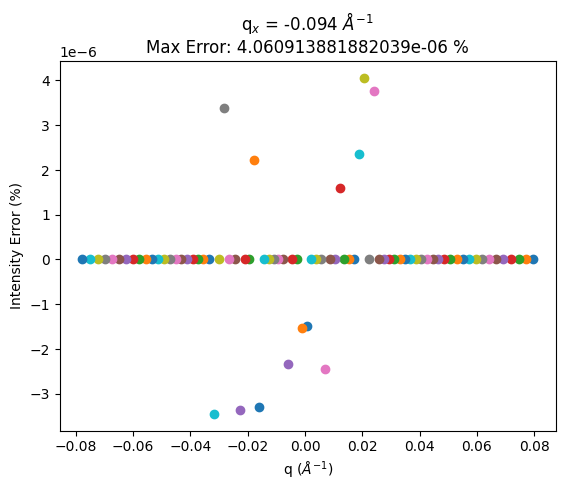

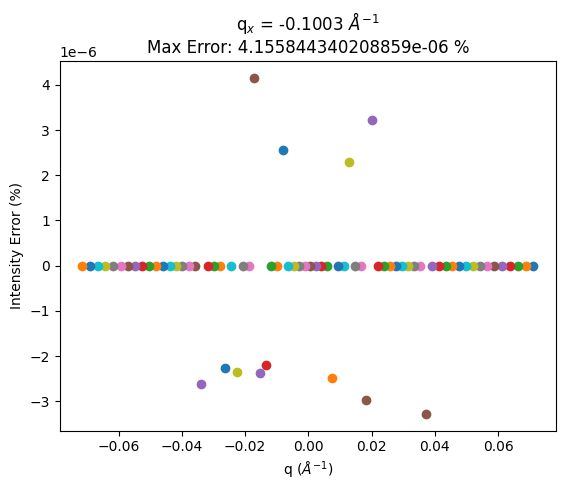

In [69]:
# plot error between the refactored code and legacy gui slices
# the intensity from the refactored code is divided by 2 (the count time in seconds) as this normalization feature is not yet available in the refactored code
%matplotlib inline
all_max_errors = []
for qx in legacy_slices.keys():
    plt.figure()
    slice_legacy = legacy_slices[qx]
    slice_refactor = refactored_slices[-1*qx]

    max_error = 0
    for i, q in enumerate(slice_legacy.q):
        close_match = np.argmin(np.abs(-1*slice_refactor.q - q))
        q_close = -1*slice_refactor.q[close_match]
        # only match up pairs that are sufficiently close in q
        q_error = np.abs((q-q_close)*100/q)
        if q_error <= 0.1:
            error = (slice_refactor.Iq[close_match] - slice_legacy.Iq[i])*100/slice_legacy.Iq[i]
            plt.scatter(q, error)
            if np.abs(error) > np.abs(max_error):
                max_error = error

    all_max_errors.append(max_error)
    # plt.xlim(-0.001, 0.001)
    
    plt.title(r"q$_x$ = "+str(qx)+r" $\AA^{-1}$"+"\nMax Error: "+str(np.abs(max_error))+" %")
    plt.ylabel("Intensity Error (%)")
    plt.xlabel(r"q ($\AA^{-1}$)")
    plt.show()
    plt.close()

    # break

In [72]:
np.max(all_max_errors)

np.float64(9.67742030131122e-06)